💡 **Environment:** `clamp-analyses`  


# Description

Reads the aggregated prediction results from `10_prediction_performance.ipynb` and creates ROC and precision-recall curve figures.

# Module loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)

from pyprojroot import here

# Settings

In [ ]:
PREDICTIONS_DIR = here('output/03_model_biology/00_archs4/02_drug_disease_associations/10_prediction_performance') / 'lincs' / 'predictions'
display(PREDICTIONS_DIR)
assert PREDICTIONS_DIR.exists()

OUTPUT_FIGURES_DIR = here('output/03_model_biology/00_archs4/02_drug_disease_associations/11_prediction_performance_plots') / 'figures'
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_FIGURES_DIR)

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/10_prediction_performance/lincs/predictions')

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/11_prediction_performance_plots/figures')

# Load predictions

In [4]:
predictions_avg = pd.read_pickle(PREDICTIONS_DIR / 'predictions_results_aggregated.pkl')
display(predictions_avg.shape)
display(predictions_avg.head())

(2740, 5)

,trait,drug,method,score,true_class
0,DOID:0050741,DB00215,gene_based,316134.3,1.0
1,DOID:0050741,DB00215,module_based_archs4,324870.1,1.0
2,DOID:0050741,DB00215,module_based_gtex,349350.5,1.0
3,DOID:0050741,DB00215,module_based_recount2,398655.9,1.0
4,DOID:0050741,DB00704,gene_based,387103.6,1.0


# Rename methods

In [ ]:
_method_rename = {
    'module_based_archs4': 'ARCHS4 LV-based',
    'module_based_gtex': 'GTEx LV-based',
    'module_based_recount2': 'recount2 LV-based',
}

METHOD_ORDER = (
    'gene_based',
    'ARCHS4 LV-based',
    'GTEx LV-based',
    'recount2 LV-based',
)

predictions_avg = predictions_avg.replace({'method': _method_rename})
predictions_avg = predictions_avg[predictions_avg['method'].isin(METHOD_ORDER)].copy()
predictions_avg['method'] = pd.Categorical(
    predictions_avg['method'], categories=METHOD_ORDER, ordered=True
)
predictions_avg = predictions_avg.sort_values('method')
display(predictions_avg['method'].unique())

/tmp/ipykernel_3302921/2786545150.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  predictions_avg = predictions_avg.replace({'method': _method_rename})


['gene_based', 'ARCHS4 LV-based', 'GTEx LV-based', 'recount2 LV-based']
Categories (4, object): ['gene_based' < 'ARCHS4 LV-based' < 'GTEx LV-based' < 'recount2 LV-based']

# Plot settings

In [ ]:
methods_names = tuple(predictions_avg['method'].cat.categories)
assert len(methods_names) == 4
display(methods_names)

methods_colors = {
    'gene_based': '#444444',
    'ARCHS4 LV-based': '#1f77b4',
    'GTEx LV-based': '#2ca02c',
    'recount2 LV-based': '#d62728',
}

('gene_based', 'ARCHS4 LV-based', 'GTEx LV-based', 'recount2 LV-based')

# ROC functions

In [7]:
def plot_roc(data, method_key, fig, ax):
    roc_auc = roc_auc_score(data['true_class'], data['score'])
    fpr, tpr, _ = roc_curve(data['true_class'], data['score'])

    label = f'{method_key} - AUC: {roc_auc:.3f}'
    sns.lineplot(
        x=fpr,
        y=tpr,
        estimator=None,
        label=label,
        ax=ax,
        linewidth=1.00,
        linestyle='-',
        color=methods_colors[method_key],
    )


def plot_roc_for_methods(selected_methods, fig, ax):
    for method_name in selected_methods:
        data = predictions_avg[predictions_avg['method'] == method_name]
        plot_roc(data, method_name, fig, ax)

    ax.plot([0.0, 1.00], [0.0, 1.00], color='gray', linewidth=1.25, linestyle='-')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.legend(loc='lower right')

# PR functions

In [8]:
def plot_pr_raw_data(recall, precision, label, **kwargs):
    sns.lineplot(x=recall, y=precision, label=label, **kwargs)


def plot_pr(data, method_key, fig, ax):
    precision, recall, _ = precision_recall_curve(data['true_class'], data['score'])
    ap = average_precision_score(data['true_class'], data['score'])

    label = f'{method_key} - AP: {ap:.3f}'
    plot_pr_raw_data(
        recall,
        precision,
        label,
        estimator=None,
        ax=ax,
        linewidth=1.00,
        linestyle='-',
        color=methods_colors[method_key],
    )


def get_random_classifier_pr(data, reps=100):
    random_precision = []
    random_recall = []
    random_average_precision = []

    for _ in range(reps):
        random_score = np.random.permutation(data['score'].values)
        rp, rr, _ = precision_recall_curve(data['true_class'], random_score)
        random_precision.extend(rp)
        random_recall.extend(rr)
        random_average_precision.append(
            average_precision_score(data['true_class'], random_score)
        )

    return (
        np.array(random_recall),
        np.array(random_precision),
        np.array(random_average_precision),
    )


def plot_pr_for_methods(selected_methods, fig, ax):
    for method_name in selected_methods:
        data = predictions_avg[predictions_avg['method'] == method_name]
        plot_pr(data, method_name, fig, ax)

    # add random classifier
    random_recall, random_precision, random_averages = get_random_classifier_pr(data, reps=100)

    random_label = f'Random - AP: {random_averages.mean():.3f}'
    plot_pr_raw_data(
        random_recall,
        random_precision,
        random_label,
        estimator='mean',
        ax=ax,
        errorbar='sd', 
        color='gray',
    )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0.0, 1.01])
    ax.set_ylim([0.60, 1.02])
    ax.legend(loc='lower right')

# Combined ROC + PR plot

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/11_prediction_performance_plots/figures/roc_pr_curves.svg')

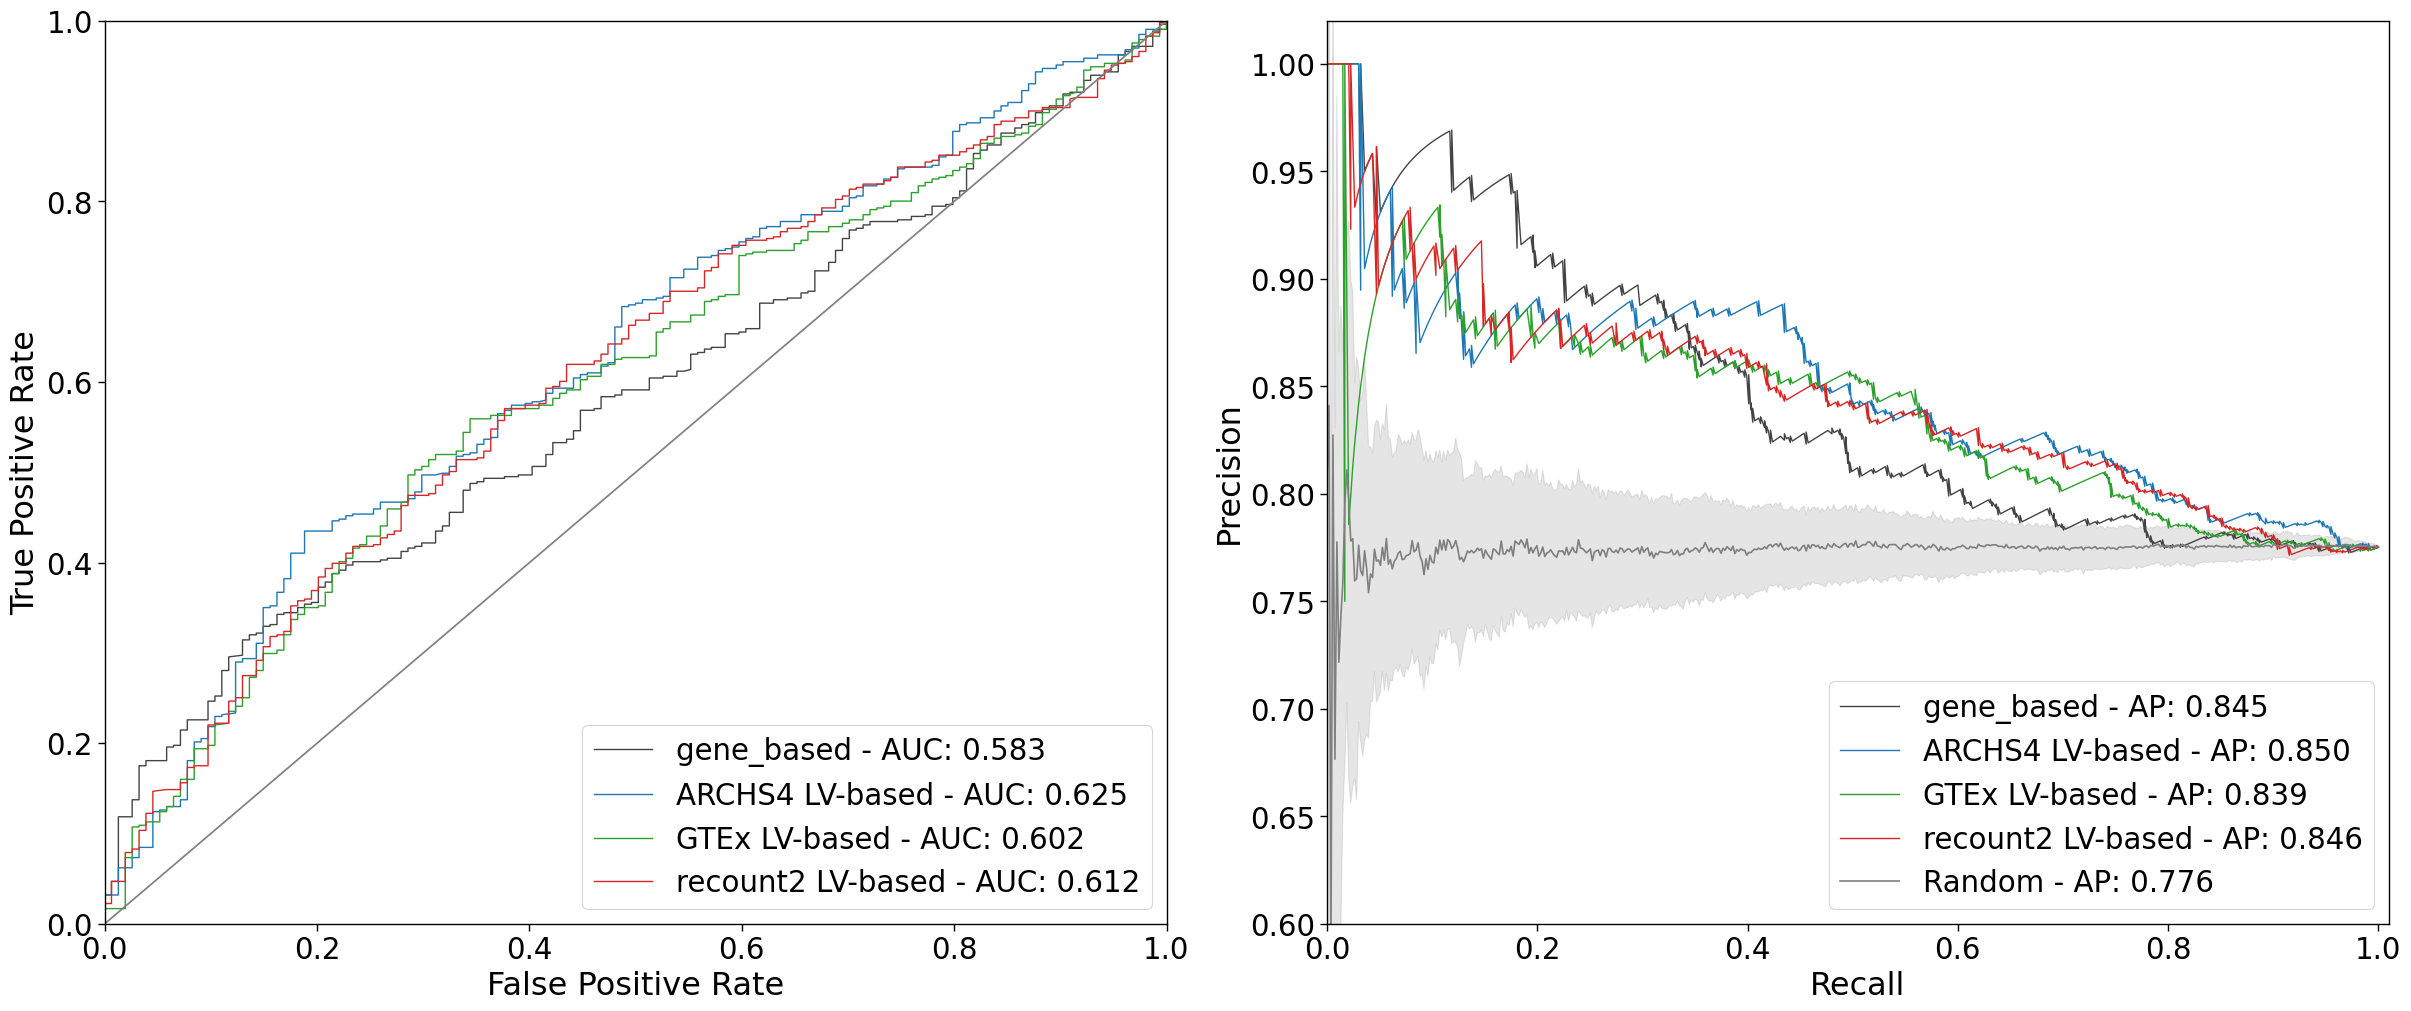

In [ ]:
with sns.plotting_context('paper', font_scale=2.4):
    fig, axes = plt.subplots(1, 2, figsize=(24, 10), constrained_layout=True)

    plot_roc_for_methods(methods_names, fig, axes[0])
    plot_pr_for_methods(methods_names, fig, axes[1])

    output_filepath = OUTPUT_FIGURES_DIR / 'roc_pr_curves.svg'
    display(output_filepath)

    plt.savefig(
        output_filepath,
        bbox_inches='tight',
        facecolor='white',
    )

## Export for Figure 4

In [10]:
from pyprojroot import here as _here

PANEL_DIR_FIG4 = _here() / 'output' / '99_panels' / 'fig4'
PANEL_DIR_FIG4.mkdir(parents=True, exist_ok=True)

# Compute AUROC and AUPRC per method
perf_rows = []
for method in METHOD_ORDER:
    df_m = predictions_avg[predictions_avg['method'] == method]
    auroc = roc_auc_score(df_m['true_class'], df_m['score'])
    auprc = average_precision_score(df_m['true_class'], df_m['score'])
    perf_rows.append({'method': method, 'auroc': auroc, 'auprc': auprc})

perf_df = pd.DataFrame(perf_rows)
perf_df.to_csv(PANEL_DIR_FIG4 / 'drug_disease_performance.csv', index=False)

# Also export ROC and PR curve coordinates for all methods
roc_rows, pr_rows = [], []
for method in METHOD_ORDER:
    df_m = predictions_avg[predictions_avg['method'] == method]
    fpr, tpr, _ = roc_curve(df_m['true_class'], df_m['score'])
    prec, rec, _ = precision_recall_curve(df_m['true_class'], df_m['score'])
    for f, t in zip(fpr, tpr):
        roc_rows.append({'method': method, 'fpr': f, 'tpr': t})
    for p, r in zip(prec, rec):
        pr_rows.append({'method': method, 'precision': p, 'recall': r})

pd.DataFrame(roc_rows).to_csv(PANEL_DIR_FIG4 / 'drug_disease_roc_curves.csv', index=False)
pd.DataFrame(pr_rows).to_csv(PANEL_DIR_FIG4 / 'drug_disease_pr_curves.csv', index=False)

print(f"Exported to {PANEL_DIR_FIG4}")
print(perf_df.to_string(index=False))

Exported to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig4
           method    auroc    auprc
       gene_based 0.583382 0.844942
  ARCHS4 LV-based 0.625419 0.849646
    GTEx LV-based 0.602484 0.839313
recount2 LV-based 0.612267 0.845789
